In [11]:
# 必要なモジュールをインポート
import os
import glob
import cv2
import re

# 対象ディレクトリ
video_dir = r"C:\Users\MSAD\github\nnspike\storage\20251003\videos"
output_base_dir = r"C:\Users\MSAD\github\nnspike\storage\20251003\frames"

# ディレクトリ内の全aviファイルを取得
video_files = glob.glob(os.path.join(video_dir, "*.avi"))

for video_path in video_files:
    # ファイル名から14桁のタイムスタンプのみ抽出（例: 20251028122115_picamera.avi → 20251028122115）
    filename = os.path.splitext(os.path.basename(video_path))[0]
    m = re.match(r"^(\d{14})", filename)
    if m:
        dir_name = m.group(1)
    else:
        dir_name = filename  # 14桁がなければ元のファイル名
    output_dir = os.path.join(output_base_dir, dir_name)
    os.makedirs(output_dir, exist_ok=True)
    print(f"動画ファイル: {video_path}")
    print(f"出力ディレクトリ: {output_dir}")

    if os.path.exists(video_path):
        print("✓ 動画ファイルが見つかりました")
        cap = cv2.VideoCapture(video_path)
        if cap.isOpened():
            frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            fps = cap.get(cv2.CAP_PROP_FPS)
            print(f"総フレーム数: {frame_count}")
            print(f"FPS: {fps}")

            frame_idx = 0
            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                frame_filename = f"frame_{frame_idx:06d}.jpg"
                frame_path = os.path.join(output_dir, frame_filename)
                cv2.imwrite(frame_path, frame)
                if frame_idx % 100 == 0:
                    print(f"フレーム {frame_idx} / {frame_count} 処理中...")
                frame_idx += 1
            cap.release()
            print(f"✓ フレーム抽出が完了しました")
            print(f"✓ 抽出されたフレーム数: {frame_idx} 枚")
        else:
            print("✗ 動画ファイルを開けませんでした")
    else:
        print("✗ 動画ファイルが見つかりません")

動画ファイル: C:\Users\MSAD\github\nnspike\storage\20251003\videos\20250909173756_picamera.avi
出力ディレクトリ: C:\Users\MSAD\github\nnspike\storage\20251003\frames\20250909173756
✓ 動画ファイルが見つかりました
総フレーム数: 1626
FPS: 30.0
フレーム 0 / 1626 処理中...
フレーム 0 / 1626 処理中...
フレーム 100 / 1626 処理中...
フレーム 100 / 1626 処理中...
フレーム 200 / 1626 処理中...
フレーム 200 / 1626 処理中...
フレーム 300 / 1626 処理中...
フレーム 300 / 1626 処理中...
フレーム 400 / 1626 処理中...
フレーム 400 / 1626 処理中...
フレーム 500 / 1626 処理中...
フレーム 500 / 1626 処理中...
フレーム 600 / 1626 処理中...
フレーム 600 / 1626 処理中...
フレーム 700 / 1626 処理中...
フレーム 700 / 1626 処理中...
フレーム 800 / 1626 処理中...
フレーム 800 / 1626 処理中...
フレーム 900 / 1626 処理中...
フレーム 900 / 1626 処理中...
フレーム 1000 / 1626 処理中...
フレーム 1000 / 1626 処理中...
フレーム 1100 / 1626 処理中...
フレーム 1100 / 1626 処理中...
フレーム 1200 / 1626 処理中...
フレーム 1200 / 1626 処理中...
フレーム 1300 / 1626 処理中...
フレーム 1300 / 1626 処理中...
フレーム 1400 / 1626 処理中...
フレーム 1400 / 1626 処理中...
フレーム 1500 / 1626 処理中...
フレーム 1500 / 1626 処理中...
フレーム 1600 / 1626 処理中...
フレーム 1600 / 1626 処理中...
✓

抽出されたフレームファイル数: 4560
最初のフレーム: frame_000000.jpg
最後のフレーム: frame_004559.jpg


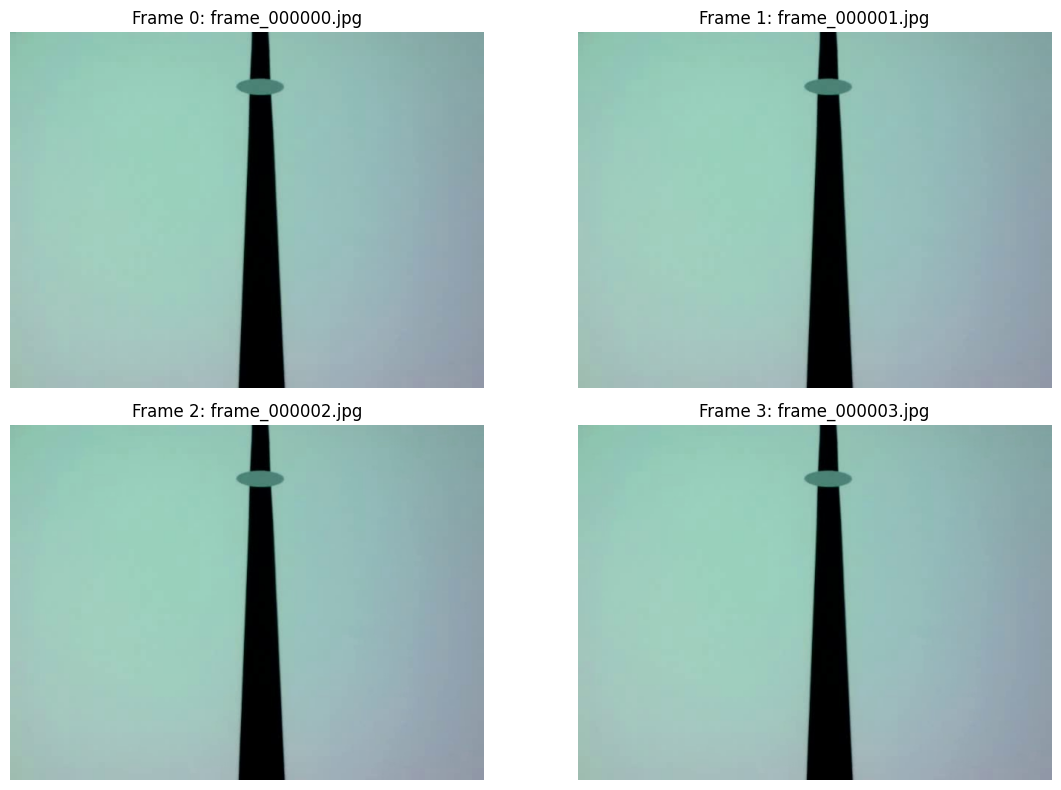


フレームファイルは以下のディレクトリに保存されました:
C:\Users\MSAD\github\nnspike\storage\20251003\frames\20251003181911


In [12]:
# 抽出結果の確認
import matplotlib.pyplot as plt

# 抽出されたフレームファイルを取得
frame_files = sorted(glob.glob(os.path.join(output_dir, "*.jpg")))
print(f"抽出されたフレームファイル数: {len(frame_files)}")

# 最初の数フレームを表示
if len(frame_files) > 0:
    print(f"最初のフレーム: {os.path.basename(frame_files[0])}")
    print(f"最後のフレーム: {os.path.basename(frame_files[-1])}")
    
    # 最初の4フレームを表示
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    for i in range(min(4, len(frame_files))):
        frame = cv2.imread(frame_files[i])
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        axes[i].imshow(frame_rgb)
        axes[i].set_title(f"Frame {i}: {os.path.basename(frame_files[i])}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nフレームファイルは以下のディレクトリに保存されました:")
    print(f"{output_dir}")
else:
    print("フレームファイルが見つかりません")

In [13]:
import sys
sys.path.append('..')

import os
import re
import glob
import pandas as pd

from nnspike.utils import extract_video_frames
from nnspike.data import create_label_dataframe, sort_by_frames_number, label_dataset_by_opencv, label_dataset_by_model, augment_dataset, set_spike_status
from nnspike.constants import  ROI_CNN

course = "right" # "right" or "left"

## Extract Frames from Videos

In [14]:
def get_all_avi_files(directory_path="C:/Users/MSAD/github/nnspike/storage/20251031/videos/", filter_timestamp=None):
    """
    Get all AVI files from the specified directory with their timestamps.
    
    Args:
        directory_path (str): Path to the directory containing AVI files
        filter_timestamp (str, optional): If set, only return files matching this timestamp pattern (supports wildcards with *)
    
    Returns:
        list: List of tuples containing (file_path, timestamp)
    """
    import os
    import glob
    import re
    import fnmatch

    # Use glob to find all .avi files in the directory
    avi_files = glob.glob(os.path.join(directory_path, "*.avi"))
    avi_files = [path.replace("\\", "/") for path in avi_files]
    
    # Sort the files for consistent ordering
    avi_files.sort()
    
    # Extract timestamps and create tuples
    result = []
    for avi_file in avi_files:
        # Extract filename without extension
        filename = os.path.basename(avi_file)
        filename_no_ext = os.path.splitext(filename)[0]
        
        # Extract timestamp from filename (assuming format: timestamp_picamera.avi)
        # This will extract the part before '_picamera'
        timestamp_match = re.match(r'^(\d{14})_.*', filename_no_ext)
        if timestamp_match:
            timestamp = timestamp_match.group(1)
        else:
            # If timestamp pattern not found, use the full filename without extension
            timestamp = filename_no_ext

        # If filter_timestamp is set, only include matching files using pattern matching
        if filter_timestamp is None or fnmatch.fnmatch(timestamp, filter_timestamp):
            result.append((avi_file, timestamp))
    
    return result

def extract_frames_from_avi_files(avi_files_with_timestamps, base_output_dir="C:/Users/MSAD/github/nnspike/storage/20251031/frames/"):
    """
    Extract frames from all AVI files and save them to folders named by timestamp.
    
    Args:
        avi_files_with_timestamps (list): List of tuples containing (file_path, timestamp)
        base_output_dir (str): Base directory where frame folders will be created
    
    Returns:
        list: List of tuples containing (output_directory, timestamp)
    """
    output_directories_with_timestamps = []
    
    for avi_file, timestamp in avi_files_with_timestamps:
        # Create output directory path
        output_dir = os.path.join(base_output_dir, timestamp)
        
        # Create directory if it doesn't exist
        os.makedirs(output_dir, exist_ok=True)
        
        # Add trailing slash for extract_video_frames function
        output_dir_with_slash = output_dir + "/"
        
        filename = os.path.basename(avi_file)
        print(f"Extracting frames from {filename} to {output_dir_with_slash}")
        
        try:
            # Extract frames using the nnspike utility function
            extract_video_frames(avi_file, output_dir_with_slash)
            print(f"✓ Successfully extracted frames to {timestamp}/")
            # Add successful output directory and timestamp to the list
            output_directories_with_timestamps.append((output_dir, timestamp))
        except Exception as e:
            print(f"✗ Error extracting frames from {filename}: {str(e)}")
    
    return output_directories_with_timestamps



In [15]:
# Get all AVI files with their timestamps
avi_files_with_timestamps = get_all_avi_files(directory_path="C:/Users/MSAD/github/nnspike/storage/20251031/videos/")
avi_files_with_timestamps

[('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028122115_picamera.avi',
  '20251028122115'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028122918_picamera.avi',
  '20251028122918'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028123055_picamera.avi',
  '20251028123055'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028123204_picamera.avi',
  '20251028123204'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028123544_picamera.avi',
  '20251028123544'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028123952_picamera.avi',
  '20251028123952'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028124054_picamera.avi',
  '20251028124054'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028124409_picamera.avi',
  '20251028124409'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/videos/20251028124551_picamera.avi',
  '20251028124551'),
 ('C:/Users/MSAD/github/nnspike/stora

In [16]:
    # Extract frames from all AVI files
if avi_files_with_timestamps:
    print("\nStarting frame extraction...")
    output_dirs_with_timestamps = extract_frames_from_avi_files(avi_files_with_timestamps, base_output_dir="C:/Users/MSAD/github/nnspike/storage/20251031/frames/")
    print("\nFrame extraction completed!")
    print(f"Successfully created {len(output_dirs_with_timestamps)} output directories:")
    for output_dir, timestamp in output_dirs_with_timestamps:
        print(f"  - {output_dir} (timestamp: {timestamp})")
else:
    print("No AVI files found to process.")
    output_dirs_with_timestamps = []
    
output_dirs_with_timestamps


Starting frame extraction...
Extracting frames from 20251028122115_picamera.avi to C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028122115/
Frames extracted to: C:\Users\MSAD\github\nnspike\storage\20251031\frames\20251028122115
✓ Successfully extracted frames to 20251028122115/
Extracting frames from 20251028122918_picamera.avi to C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028122918/
Frames extracted to: C:\Users\MSAD\github\nnspike\storage\20251031\frames\20251028122115
✓ Successfully extracted frames to 20251028122115/
Extracting frames from 20251028122918_picamera.avi to C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028122918/
Frames extracted to: C:\Users\MSAD\github\nnspike\storage\20251031\frames\20251028122918
✓ Successfully extracted frames to 20251028122918/
Extracting frames from 20251028123055_picamera.avi to C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028123055/
Frames extracted to: C:\Users\MSAD\github\nnspike\storage\

[('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028122115',
  '20251028122115'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028122918',
  '20251028122918'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028123055',
  '20251028123055'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028123204',
  '20251028123204'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028123544',
  '20251028123544'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028123952',
  '20251028123952'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028124054',
  '20251028124054'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028124409',
  '20251028124409'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028124551',
  '20251028124551'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028130745',
  '20251028130745'),
 ('C:/Users/MSAD/github/nnspike/storage/20251031/frames/2025

In [17]:
import os
for output_dir, timestamp in output_dirs_with_timestamps:
    print(f"Output directory: {output_dir} (timestamp: {timestamp})")
    
    course = "right"
    label_df = create_label_dataframe(output_dir +"/*", course)
    if label_df is None or label_df.empty:
        print(f"Warning: label_df is empty for timestamp {timestamp}, skipping.")
        continue
    print("label_df type:", type(label_df))
    print("label_df head:", getattr(label_df, "head", lambda: "no head")())
    label_df = sort_by_frames_number(label_df)
    label_df = label_dataset_by_opencv(label_df, ROI_CNN, 80)
    
    sensor_path = f"C:/Users/MSAD/github/nnspike/storage/20251031/sensor_data/{timestamp}_sensor_log.csv"
    if not os.path.exists(sensor_path):
        print(f"Warning: Sensor log not found for timestamp {timestamp}, skipping.")
        continue
    
    status_df = pd.read_csv(sensor_path)
    df = set_spike_status(label_df, status_df)
    
    # Export to a csv file
    df.to_csv(f"C:/Users/MSAD/github/nnspike/storage/20251031/labels/{timestamp}_label.csv", index=False)

Output directory: C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028122115 (timestamp: 20251028122115)
label_df type: <class 'pandas.core.frame.DataFrame'>
label_df head:                                           image_path  mode  target_x  left_x  \
0  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
1  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
2  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
3  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
4  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   

   right_x  motor_a_speed  motor_b_speed  motor_a_relative_position  \
0      NaN              0              0                          0   
1      NaN              0              0                          0   
2      NaN              0              0                          0   
3      NaN              0              0             

Processing: 100%|██████████| 4133/4133 [01:15<00:00, 54.52it/s]



Output directory: C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028122918 (timestamp: 20251028122918)
label_df type: <class 'pandas.core.frame.DataFrame'>
label_df head:                                           image_path  mode  target_x  left_x  \
0  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
1  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
2  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
3  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
4  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   

   right_x  motor_a_speed  motor_b_speed  motor_a_relative_position  \
0      NaN              0              0                          0   
1      NaN              0              0                          0   
2      NaN              0              0                          0   
3      NaN              0              0             

Processing: 100%|██████████| 1030/1030 [00:19<00:00, 53.28it/s]



Output directory: C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028123055 (timestamp: 20251028123055)
label_df type: <class 'pandas.core.frame.DataFrame'>
label_df head:                                           image_path  mode  target_x  left_x  \
0  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
1  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
2  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
3  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
4  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   

   right_x  motor_a_speed  motor_b_speed  motor_a_relative_position  \
0      NaN              0              0                          0   
1      NaN              0              0                          0   
2      NaN              0              0                          0   
3      NaN              0              0             

...

Processing: 100%|██████████| 6463/6463 [01:32<00:00, 69.90it/s]



Output directory: C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028170127 (timestamp: 20251028170127)
label_df type: <class 'pandas.core.frame.DataFrame'>
label_df head:                                           image_path  mode  target_x  left_x  \
0  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
1  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
2  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
3  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
4  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   

   right_x  motor_a_speed  motor_b_speed  motor_a_relative_position  \
0      NaN              0              0                          0   
1      NaN              0              0                          0   
2      NaN              0              0                          0   
3      NaN              0              0             

Processing: 100%|██████████| 611/611 [00:08<00:00, 73.27it/s]



Output directory: C:/Users/MSAD/github/nnspike/storage/20251031/frames/20251028170247 (timestamp: 20251028170247)
label_df type: <class 'pandas.core.frame.DataFrame'>
label_df head:                                           image_path  mode  target_x  left_x  \
0  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
1  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
2  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
3  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   
4  C:/Users/MSAD/github/nnspike/storage/20251031/...   NaN       NaN     NaN   

   right_x  motor_a_speed  motor_b_speed  motor_a_relative_position  \
0      NaN              0              0                          0   
1      NaN              0              0                          0   
2      NaN              0              0                          0   
3      NaN              0              0             

Processing: 100%|██████████| 5957/5957 [01:43<00:00, 57.33it/s]

